# Patterned Loading
This is an implementation of the Patterned Loading feature. For the design specification please see the document Specification.md.

Ultimately, these tools will be used to reproduce the Patterned Loading experiments explained in the paper by S. Peil
1. Peil, S. & Porto, J. & Tolra, & Laburthe, B. & Obrecht, John & King, B. & Subbotin, M. & Rolston, Steven & Phillips, William. (2003). Patterned loading of a Bose-Einstein condensate into an optical lattice. Phys. Rev. A. 67. 051603. 10.1103/PhysRevA.67.051603. 

In [1]:
from oqtant.schemas.quantum_matter import QuantumMatterFactory
from oqtant.schemas.quantum_matter import QuantumMatter as qm
from oqtant.schemas.output import Gaussian_dist_2D
import numpy as np
import matplotlib.pyplot as plt

qmf = QuantumMatterFactory()
qmf.get_login()

Auth(children=(HBox(children=(Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x12\x00\x00\x00\xc…

In [2]:
qmf.get_client()

Job Limits:
╒═══════════════╤═══════════════════╤════════════════════╤════════════════════╕
│   Daily Limit │   Daily Remaining │   Standard Credits │   Priority Credits │
╞═══════════════╪═══════════════════╪════════════════════╪════════════════════╡
│            20 │                20 │                 64 │                  0 │
╘═══════════════╧═══════════════════╧════════════════════╧════════════════════╛


In [3]:
from PatternedLoadingPkg.patterned_loader import PatternedLoader

In [4]:
recoilE = 3.8
shortPot = 20*recoilE
longPot = 2*recoilE
shortPot

76.0

### Experiment 1: Superlattice

In [5]:
pl = PatternedLoader(qmf)

s_pot = shortPot #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 2. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = longPot #kHz
l_delay = 0. #ms
l_rise = 2. #ms also fall
l_hold = 2. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

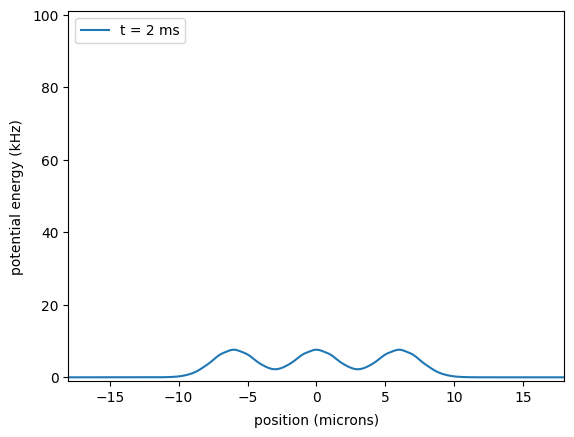

In [6]:
pl.get_matter("t").show_potential(times=[2], include_ideal=False, include_magnetic=False, xlimits=[-18,18])

In [7]:
repeats = 5
jobs = []
for rep in range(repeats):
    name = "SuperlatticeExpt_it_821" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [8]:
sim = False
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

Submitting 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_0
  Job ID: 0cfdfa00-9927-4d4e-8431-374a5711566b

Tracking 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_0
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_1
  Job ID: 98588f32-303c-44a8-8481-197251cb8507

Tracking 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_1
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_2
  Job ID: b48509ad-0e44-46a2-af2e-036885cb426b

Tracking 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_2
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_3
  Job ID: 1c102c58-98b1-4f82-ad0a-e28c44942071

Tracking 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_3
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: SuperlatticeExpt_it_821_rep_4
  Job ID: f1b0d25a-c830-4eeb-ac38-2e9a9db7fe5f

Tracking 1 job(s):

- Job: SuperlatticeExpt_it_821_re

[None, None, None, None, None]

In [9]:
[matter.get_result() for matter in jobs]

[None, None, None, None, None]

In [10]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\SuperlatticeExpt_it_821_rep_0.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\SuperlatticeExpt_it_821_rep_1.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\SuperlatticeExpt_it_821_rep_2.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\SuperlatticeExpt_it_821_rep_3.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\SuperlatticeExpt_it_821_rep_4.txt"


### Experiment 2: Long Only

In [11]:
pl = PatternedLoader(qmf, "LongOnlyExpt")

s_pot = 0.0 #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 2. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = longPot #kHz
l_delay = 0. #ms
l_rise = 2. #ms also fall
l_hold = 2. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

In [12]:
repeats = 5
jobs = []
for rep in range(repeats):
    name = "LongOnlyExpt_it_821" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [13]:
sim = False
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

Submitting 1 job(s):

- Job: LongOnlyExpt_it_821_rep_0
  Job ID: ffa72f84-30c9-4ab2-a451-c7070bef8255

Tracking 1 job(s):

- Job: LongOnlyExpt_it_821_rep_0
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: LongOnlyExpt_it_821_rep_1
  Job ID: 025fec1c-b880-4594-aba5-9aa542200fcd

Tracking 1 job(s):

- Job: LongOnlyExpt_it_821_rep_1
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: LongOnlyExpt_it_821_rep_2
  Job ID: 7879b76c-ae09-4a6f-9106-2b3d63dc253a

Tracking 1 job(s):

- Job: LongOnlyExpt_it_821_rep_2
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: LongOnlyExpt_it_821_rep_3
  Job ID: 0000e885-0210-4bd5-9f60-4795560a283a

Tracking 1 job(s):

- Job: LongOnlyExpt_it_821_rep_3
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: LongOnlyExpt_it_821_rep_4
  Job ID: e3f4c0dd-1f07-4954-afae-8fc2d8c07b4a

Tracking 1 job(s):

- Job: LongOnlyExpt_it_821_rep_4
  - RUNNING
  - COMPLETE

All job(s)

[None, None, None, None, None]

In [14]:
[matter.get_result() for matter in jobs]

[None, None, None, None, None]

In [15]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\LongOnlyExpt_it_821_rep_0.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\LongOnlyExpt_it_821_rep_1.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\LongOnlyExpt_it_821_rep_2.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\LongOnlyExpt_it_821_rep_3.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\LongOnlyExpt_it_821_rep_4.txt"


### Experiment 3: Short Only

In [16]:
pl = PatternedLoader(qmf, "ShortOnlyExpt")

s_pot = shortPot #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 2. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = 0. #kHz
l_delay = 0. #ms
l_rise = 2. #ms also fall
l_hold = 2. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

In [17]:
repeats = 5
jobs = []
for rep in range(repeats):
    name = "ShortOnlyExpt_it_821" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [18]:
sim = False
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

Submitting 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_0
  Job ID: 27d7d60a-22c1-4dda-9f6e-f7a75b85a2e8

Tracking 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_0
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_1
  Job ID: ecb9fb7f-57a5-47f2-aa71-7153d3a60dc4

Tracking 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_1
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_2
  Job ID: 980785fa-484b-4375-8c74-a5ddd5b9cb6e

Tracking 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_2
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_3
  Job ID: 7859d82b-d3fe-444f-8828-469060869ec1

Tracking 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_3
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_4
  Job ID: e53b4653-ff81-4296-81ef-7ac03f5d95c7

Tracking 1 job(s):

- Job: ShortOnlyExpt_it_821_rep_4
  - RUNNING
  - COMPLETE



[None, None, None, None, None]

In [19]:
[matter.get_result() for matter in jobs]

[None, None, None, None, None]

In [20]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\ShortOnlyExpt_it_821_rep_0.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\ShortOnlyExpt_it_821_rep_1.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\ShortOnlyExpt_it_821_rep_2.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\ShortOnlyExpt_it_821_rep_3.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\ShortOnlyExpt_it_821_rep_4.txt"


### Experiment 4: No Pattern

In [21]:
pl = PatternedLoader(qmf, "NoPattern")

s_pot = 0.0 #kHz
s_delay = 2. #ms
s_rise = 2. #ms also fall
s_hold = 2. #ms
short = pl.Lattice()
short.set_potential(s_pot)
short.set_loading_seq(s_delay, s_rise, s_hold)

l_pot = 0. #kHz
l_delay = 0. #ms
l_rise = 2. #ms also fall
l_hold = 2. #ms
long = pl.Lattice()

long.set_potential(l_pot)
long.set_loading_seq(l_delay, l_rise, l_hold)

pl.set_superlattice(long, short)

In [22]:
repeats = 3
jobs = []
for rep in range(repeats):
    name = "NoPatternExpt_it_821" + "_rep_" + str(rep)
    jobs.append(pl.get_matter(name))

In [23]:
sim = False
track = False
if sim == False:
    track = True
[matter.submit(track=track, sim=sim) for matter in jobs]

Submitting 1 job(s):

- Job: NoPatternExpt_it_821_rep_0
  Job ID: 96ea19c2-ddf4-4082-8126-41fff0ebf443

Tracking 1 job(s):

- Job: NoPatternExpt_it_821_rep_0
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: NoPatternExpt_it_821_rep_1
  Job ID: 6b69679c-4c64-4423-88f8-8f9cfca80116

Tracking 1 job(s):

- Job: NoPatternExpt_it_821_rep_1
  - RUNNING
  - COMPLETE

All job(s) complete
Submitting 1 job(s):

- Job: NoPatternExpt_it_821_rep_2
  Job ID: 2e52d6d4-518b-42db-8b06-a5d43eeb8999

Tracking 1 job(s):

- Job: NoPatternExpt_it_821_rep_2
  - RUNNING
  - COMPLETE

All job(s) complete


[None, None, None]

In [24]:
[matter.get_result() for matter in jobs]

[None, None, None]

In [25]:
import os
home = os.path.expanduser("~")
for matter in jobs:
    data_path = f"{home}\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\\{matter.name}.txt"
    matter.write_to_file(file_path=data_path)

Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\NoPatternExpt_it_821_rep_0.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\NoPatternExpt_it_821_rep_1.txt"
Wrote file: "C:\Users\Josh\Projects\BEConOqtant\Superlattice\PatternedLoading\Data\NoPatternExpt_it_821_rep_2.txt"
